Epoch 0: Train Loss = 0.5547, Val Loss = 0.3968
Epoch 10: Train Loss = 0.1017, Val Loss = 0.0713
Epoch 20: Train Loss = 0.0888, Val Loss = 0.0674
Epoch 30: Train Loss = 0.0728, Val Loss = 0.0561
Epoch 40: Train Loss = 0.0494, Val Loss = 0.0528
Epoch 50: Train Loss = 0.0406, Val Loss = 0.0344
Epoch 60: Train Loss = 0.0395, Val Loss = 0.0319
Epoch 70: Train Loss = 0.0302, Val Loss = 0.0324
Epoch 80: Train Loss = 0.0266, Val Loss = 0.0275
Epoch 90: Train Loss = 0.0365, Val Loss = 0.0273
Epoch 100: Train Loss = 0.0328, Val Loss = 0.0277
Epoch 110: Train Loss = 0.0311, Val Loss = 0.0255
Epoch 120: Train Loss = 0.0275, Val Loss = 0.0268
Epoch 130: Train Loss = 0.0309, Val Loss = 0.0266
Epoch 140: Train Loss = 0.0294, Val Loss = 0.0255
Epoch 150: Train Loss = 0.0256, Val Loss = 0.0274
Epoch 160: Train Loss = 0.0344, Val Loss = 0.0332
Epoch 170: Train Loss = 0.0227, Val Loss = 0.0258
Epoch 180: Train Loss = 0.0308, Val Loss = 0.0272
Epoch 190: Train Loss = 0.0209, Val Loss = 0.0269


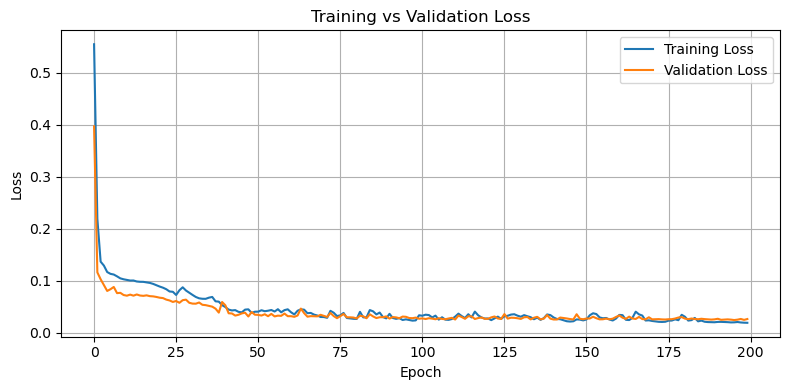


Test RMSE (IC=1.2): 0.1512
Test R² (IC=1.2):   0.6774
Total Runtime: 12.12 seconds


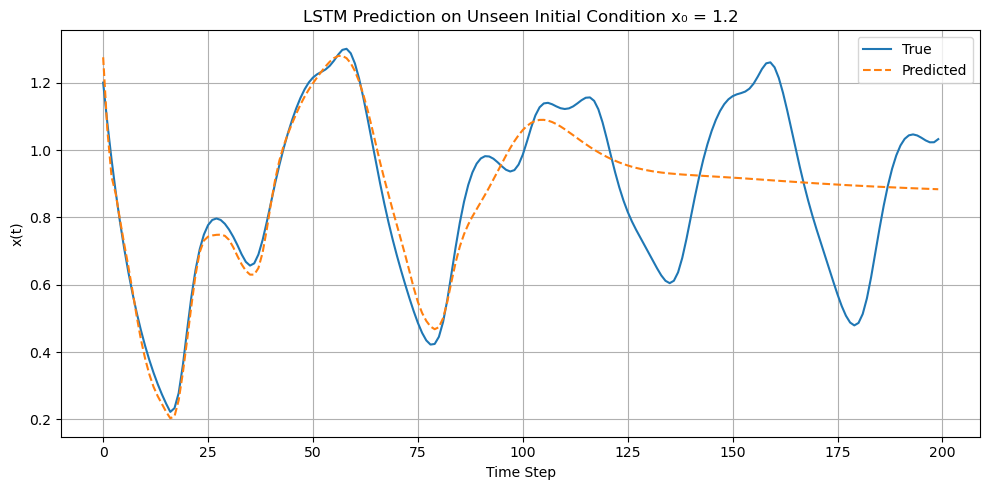

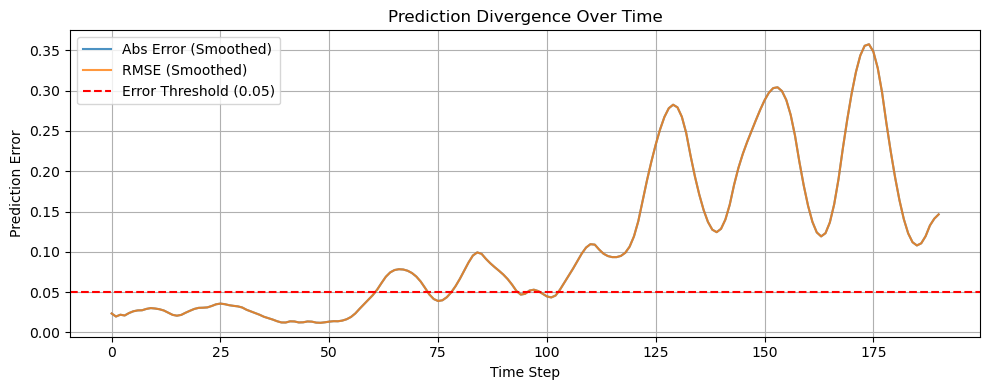

Prediction horizon at threshold 0.05: 71 steps
Total runtime: 12.53 seconds


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time

# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x

# --- Parameters ---
t_max = 200
delta_t = 1
test_ic = 1.2
train_ics_all = np.concatenate((np.linspace(0, 1.19, 20), np.linspace(1.21, 3, 20)))
train_ics_train, train_ics_val = train_test_split(train_ics_all, test_size=0.1, random_state=42)
timesteps = np.arange(0, t_max, delta_t)

# --- Feature Generator ---
def generate_data(ics, t_max):
    X_list, y_list = [], []
    for ic in ics:
        x = mackey_glass(t_max=t_max, x0=ic)
        norm_t = timesteps / t_max
        features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
        X_list.append(features)
        y_list.append(x)
    return np.vstack(X_list), np.concatenate(y_list), len(ics)

# --- Generate all sets ---
X_train, y_train, N_train = generate_data(train_ics_train, t_max)
X_val, y_val, N_val = generate_data(train_ics_val, t_max)
X_test, y_test, _ = generate_data([test_ic], t_max)

# --- Normalize ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Reshape into (ICs, Timesteps, Features) ---
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).reshape(N_train, t_max, 2)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(N_train, t_max)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).reshape(N_val, t_max, 2)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(N_val, t_max)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(0)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(0)

# --- Dataloaders ---
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

# --- LSTM Model ---
class LSTMNet(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2):
        super(LSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out).squeeze(-1)
        return out

model = LSTMNet()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Train with validation tracking ---
train_losses = []
val_losses = []
start_time = time.time()
epochs = 200
for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss = criterion(pred, yb)
            total_val_loss += val_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

end_time = time.time()

# --- Plot Training vs Validation Loss ---
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Final Test on Unseen Initial Condition ---
model.eval()
with torch.no_grad():
    pred_test = model(X_test_tensor).squeeze(0).numpy()

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)
print(f"\nTest RMSE (IC={test_ic}): {rmse:.4f}")
print(f"Test R² (IC={test_ic}):   {r2:.4f}")
print(f"Total Runtime: {end_time - start_time:.2f} seconds")

# --- Plot Test Prediction ---
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True')
plt.plot(pred_test, label='Predicted', linestyle='--')
plt.title(f"LSTM Prediction on Unseen Initial Condition x₀ = {test_ic}")
plt.xlabel("Time Step")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Divergence
errors = np.abs(pred_test - y_test)            # abs error
rmse_window = np.sqrt((pred_test - y_test)**2) # RMSE error

# Optional: smooth with moving average for clarity
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.8)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.8)
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

threshold = 0.05
divergence_time = np.argmax(smoothed_error > threshold) + window_size
print(f"Prediction horizon at threshold {threshold}: {divergence_time} steps")
end_time = time.time()

print(f"Total runtime: {end_time - start_time:.2f} seconds")

In [9]:
import torch
from torch.utils.data import DataLoader

# Use CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Expanded hyperparameter search space
hidden_sizes = [32, 64, 128, 256]
num_layers_list = [1, 2, 3]
learning_rates = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
batch_sizes = [4, 8, 16]
dropouts = [0.0, 0.2, 0.4]

# Redefine LSTM model class to accept dropout
class LSTMNet(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2, dropout=0.0):
        super(LSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out).squeeze(-1)
        return out

# Grid search
best_model = None
best_loss = float("inf")
best_config = None

for h in hidden_sizes:
    for l in num_layers_list:
        for lr in learning_rates:
            for bs in batch_sizes:
                for do in dropouts:
                    print(f"\nTraining: hidden={h}, layers={l}, lr={lr}, batch={bs}, dropout={do}")

                    # Define model, optimizer, dataloader
                    model = LSTMNet(hidden_size=h, num_layers=l, dropout=do).to(device)
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)

                    # Train for a few quick epochs
                    for epoch in range(15):
                        model.train()
                        for xb, yb in train_loader:
                            xb, yb = xb.to(device), yb.to(device)
                            optimizer.zero_grad()
                            output = model(xb)
                            loss = criterion(output, yb)
                            loss.backward()
                            optimizer.step()

                    # Evaluate on validation set
                    model.eval()
                    val_loss = 0
                    with torch.no_grad():
                        for xb, yb in val_loader:
                            xb, yb = xb.to(device), yb.to(device)
                            val_loss += criterion(model(xb), yb).item()
                    val_loss /= len(val_loader)
                    print(f"Val Loss: {val_loss:.5f}")

                    # Save best model
                    if val_loss < best_loss:
                        best_loss = val_loss
                        best_model = model
                        best_config = (h, l, lr, bs, do)

print(f"\n✅ Best Config: Hidden={best_config[0]}, Layers={best_config[1]}, "
      f"LR={best_config[2]}, Batch={best_config[3]}, Dropout={best_config[4]} "
      f"→ Val Loss={best_loss:.5f}")


Using device: cuda

Training: hidden=32, layers=1, lr=0.01, batch=4, dropout=0.0
Val Loss: 0.05354

Training: hidden=32, layers=1, lr=0.01, batch=4, dropout=0.2
Val Loss: 0.05899

Training: hidden=32, layers=1, lr=0.01, batch=4, dropout=0.4
Val Loss: 0.05055

Training: hidden=32, layers=1, lr=0.01, batch=8, dropout=0.0
Val Loss: 0.06360

Training: hidden=32, layers=1, lr=0.01, batch=8, dropout=0.2
Val Loss: 0.06794

Training: hidden=32, layers=1, lr=0.01, batch=8, dropout=0.4
Val Loss: 0.06519

Training: hidden=32, layers=1, lr=0.01, batch=16, dropout=0.0
Val Loss: 0.07151

Training: hidden=32, layers=1, lr=0.01, batch=16, dropout=0.2
Val Loss: 0.06962

Training: hidden=32, layers=1, lr=0.01, batch=16, dropout=0.4
Val Loss: 0.06263

Training: hidden=32, layers=1, lr=0.005, batch=4, dropout=0.0
Val Loss: 0.06231

Training: hidden=32, layers=1, lr=0.005, batch=4, dropout=0.2
Val Loss: 0.06488

Training: hidden=32, layers=1, lr=0.005, batch=4, dropout=0.4
Val Loss: 0.05254

Training: hidd